In [11]:
import os
from dotenv import load_dotenv
load_dotenv()

# import necessery tools
from langgraph.graph import StateGraph, START, END
from typing import TypedDict
from langchain_groq import ChatGroq
from IPython.display import Image

In [6]:
os.environ['GROQ_API_KEY'] = os.getenv("GROQ_API_KEY")

In [7]:
llm = ChatGroq(model="llama-3.3-70b-versatile")

In [8]:
llm.invoke("what is machine learning")

AIMessage(content="Machine learning (ML) is a subset of artificial intelligence (AI) that involves the use of algorithms and statistical models to enable machines to learn from data, without being explicitly programmed. In other words, machine learning allows computers to automatically improve their performance on a task, based on experience and data, rather than relying on explicit instructions.\n\n**Key Characteristics of Machine Learning:**\n\n1. **Data-driven**: Machine learning relies on large amounts of data to learn patterns, relationships, and trends.\n2. **Algorithmic**: Machine learning uses algorithms to analyze and process data, often using techniques such as regression, decision trees, clustering, and neural networks.\n3. **Self-improvement**: Machine learning systems can improve their performance over time, as they learn from new data and experiences.\n4. **Autonomous**: Machine learning systems can operate independently, without human intervention, to make predictions, c

In [21]:
# State 
class State(TypedDict):
    topic: str
    characters: str
    settings: str
    premises: str
    story_intro: str

In [22]:
def generate_characters(state: State):
    """Generate character descriptions"""
    msg = llm.invoke(f"Create two character names and brief traits for a story about {state['topic']}")
    return {"characters": msg.content}

def generate_settings(state: State):
    msg = llm.invoke(f"Describe a vivid setting for a story about {state['topic']}")
    return {"settings": msg.content}

def generate_premises(state: State):
    msg = llm.invoke(f"Write a one-sentence plot premise for a story about {state['topic']}")
    return {"premises": msg.content}


def combine_elements(state: State):
    """Combine characters, setting, and premise into an intro"""
    msg = llm.invoke(
        f"Write a short story introduction using these elements:\n"
        f"Characters: {state['characters']}\n"
        f"Setting: {state['settings']}\n"
        f"Premise: {state['premises']}"
    )
    return {"story_intro": msg.content}

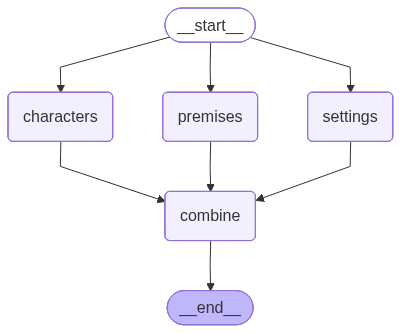

In [23]:
# buld graph
graph = StateGraph(State)

# add node
graph.add_node("characters", generate_characters)
graph.add_node("settings", generate_settings)
graph.add_node("premises", generate_premises)
graph.add_node("combine", combine_elements)

# add edges
graph.add_edge(START ,"characters") 
graph.add_edge(START, "settings") 
graph.add_edge(START, "premises")
graph.add_edge("characters", "combine") 
graph.add_edge("settings", "combine") 
graph.add_edge("premises", "combine") 
graph.add_edge("combine", END)

# Compile the graph
graph_builder = graph.compile()

# Display the image
Image(graph_builder.get_graph().draw_mermaid_png())


In [24]:
graph_builder.invoke({"topic": "programming"})

{'topic': 'programming',
 'characters': "Here are two character names and brief traits for a story about programming:\n\n1. **Ava Morales**: Ava is a brilliant and determined 25-year-old software engineer with a passion for artificial intelligence. She's resourceful, analytical, and always eager to learn new programming languages. Her sharp mind and quick thinking often help her team solve complex coding problems.\n\n2. **Ethan Kim**: Ethan is a charismatic 28-year-old tech entrepreneur who has a knack for innovation. He's a skilled programmer with expertise in web development and cybersecurity. Ethan is confident, outgoing, and has a talent for leading teams, but his impulsive decisions sometimes put him at odds with his more cautious colleagues, like Ava.",
 'settings': 'In the heart of the city, where the neon lights of towering skyscrapers reflected off the wet pavement, there existed a small, unassuming building that housed a world of code and innovation. The sign above the entran